In [1]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

I0000 00:00:1778004914.607701 1926754 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778004918.266310 1926754 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778004932.036718 1926754 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [20]:
import csv
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole 
import seaborn as sns
from joblib import load
from PIL import Image
import json, pickle
import gc
from joblib import Parallel, delayed
from copy import deepcopy


sys.path.append('../')

import macaw
print(macaw.__version__)
from macaw import *
from macaw.generators import library_evolver

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['figure.dpi'] = 96
matplotlib.rcParams['savefig.dpi'] = 600
from matplotlib.ticker import AutoMinorLocator
from scipy.stats import gaussian_kde


from copy import deepcopy
from joblib import Parallel, delayed
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%run "./plotting.py"

1.0.1


In [5]:
from art.core import RecommendationEngine
import art.utility as utils
from art.plot import predictions_vs_observations, predictions_distr_vs_observations
import pickle
import cloudpickle

In [3]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
HuggingFaceModelsDir = os.path.join(dataDir, 'HuggingFace_models/')
DORANETmoleculesDataDir = '/users/sghosh6/DTRA_project/MACAW/doranet/scripts'
resultsDir = os.path.join(dataDir, 'Results/combinedEbolaVirus_bestMACAW_allDB_generative/')
os.makedirs(resultsDir, exist_ok=True)

### Load saved `MACAW` transformer

In [6]:
macaw_load_path = os.path.join(resultsDir, "combinedEbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirusData_allDB_MACAW_transformer.joblib


### Load pre-trained `ART` model

ART model loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/ART_MACAW/ART_results/art.cpkl
ART output directory: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative


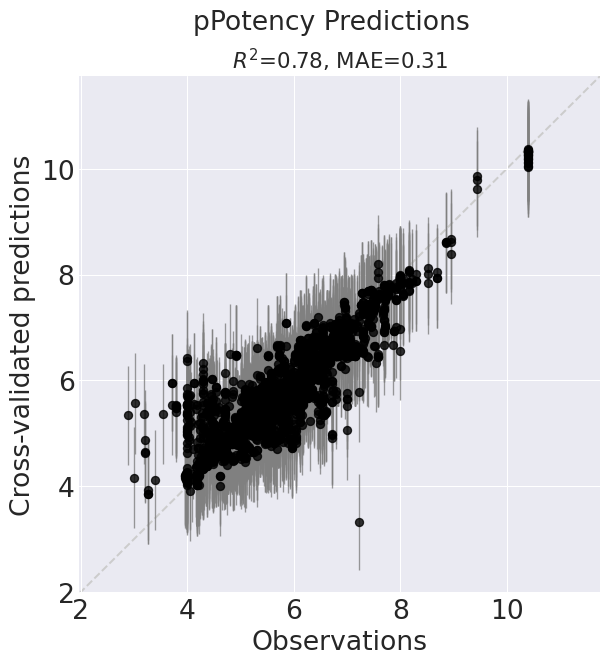

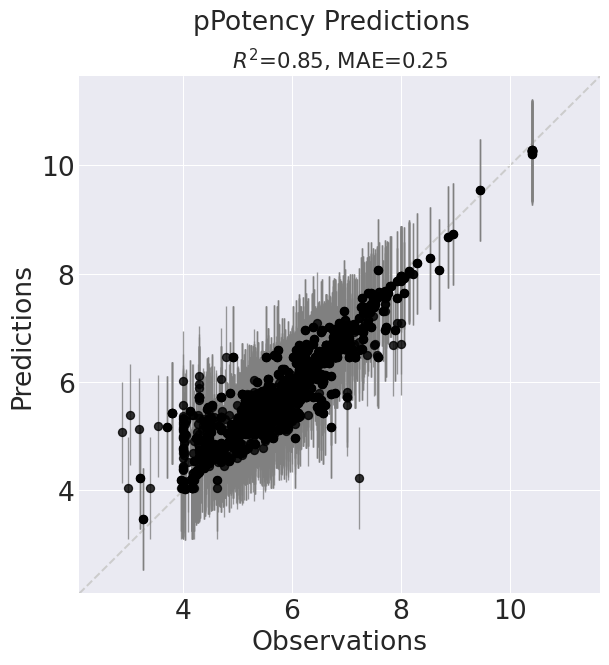

In [7]:
ARTtrainedModelFile = os.path.join(resultsDir, "ART_MACAW/ART_results/art.cpkl")
with open(ARTtrainedModelFile, "rb") as f:
    art_macaw = cloudpickle.load(f)

print(f"ART model loaded from: {ARTtrainedModelFile}")

# Force ART to use the current result directory
art_macaw.output_dir = resultsDir
os.makedirs(art_macaw.output_dir, exist_ok=True)

print(f"ART output directory: {art_macaw.output_dir}")

# Generate both ART plots
predictions_vs_observations(art_macaw,cv=True,error_bars=True)

predictions_vs_observations(art_macaw,cv=False,error_bars=True)

## Load compounds with `predicted` and `experimental` potency

### `DORAnet` generated molecules with starter: `Inosine + Adenosine + Guanosine + Xanthosine`

In [9]:
combinedEbola_allDORAnetGenerated_Antivirals_wART = pd.read_csv(resultsDir + "/combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction.csv")
combinedEbola_allDORAnetGenerated_Antivirals_wART = combinedEbola_allDORAnetGenerated_Antivirals_wART[['Canonical_SMILES', 'source_DataBase','pPotency_prediction','pPotency_std']]
combinedEbola_allDORAnetGenerated_Antivirals_wART

,Canonical_SMILES,source_DataBase,pPotency_prediction,pPotency_std
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,InosineOnly_gen3,5.691645,0.488799
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,InosineOnly_gen3,5.863623,0.479961
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,InosineOnly_gen3,5.715808,0.484744
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,InosineOnly_gen3,5.672804,0.480197
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,InosineOnly_gen3,5.700458,0.479558
...,...,...,...,...
20367,NC(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c32...,XanthosineOnly_gen3,5.596516,0.481387
20368,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,XanthosineOnly_gen3,5.600422,0.479647
20369,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,XanthosineOnly_gen3,5.586394,0.479575
20370,CNC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c...,XanthosineOnly_gen3,5.567637,0.479700


### `DORAnet + DORA-XGB` generated molecules with starter: `Remdesivir`

In [15]:
RemdesivirOnly_DORAnetGenerated_wART = pd.read_csv(resultsDir + "/RemdesivirOnly_DORAnetGenerated_ARTprediction.csv")
RemdesivirOnly_DORAnetGenerated_wART = RemdesivirOnly_DORAnetGenerated_wART[['Canonical_SMILES', 'source_DataBase','pPotency_prediction','pPotency_std']]
RemdesivirOnly_DORAnetGenerated_wART

,Canonical_SMILES,source_DataBase,pPotency_prediction,pPotency_std
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,RemdesivirOnly_gen2_doragxb,5.943201,0.508114
1,CCC(CC)COC(=O)[C@H](CC(CC)CC)N[P@](=O)(OC[C@H]...,RemdesivirOnly_gen2_doragxb,5.885631,0.495639
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CSCC[C@H](N)C(=O)O...,RemdesivirOnly_gen2_doragxb,5.717081,0.483776
3,CCCCOC(=O)[C@H](CCC)N[P@](=O)(OC[C@H]1O[C@@](C...,RemdesivirOnly_gen2_doragxb,5.883080,0.496837
4,CCC(CC)COC(=O)[C@](C)(O)N[P@](=O)(OC[C@H]1O[C@...,RemdesivirOnly_gen2_doragxb,5.964491,0.502491
...,...,...,...,...
220,OC[C@H]1O[C@H](Oc2ccccc2)[C@H](O)[C@@H](O)[C@@...,RemdesivirOnly_gen2_doragxb,5.701380,0.486752
221,N#C[C@]12O[C@H](CO)[C@@H](Oc3nc(N)c4ccc1n4n3)[...,RemdesivirOnly_gen2_doragxb,5.686895,0.489213
222,CCC(CC)COC(=O)OC(C)=O,RemdesivirOnly_gen2_doragxb,5.773113,0.477554
223,CCC(CC)[C@](C)(N[P@](=O)(OC[C@H]1O[C@@](C#N)(c...,RemdesivirOnly_gen2_doragxb,5.820786,0.496306


### Read `experimental` potency data of some known antivirals

In [14]:
querySmilesDict = {
    "Remdesivir_expt": "CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1",
    "Favipiravir_expt": "C1=C(N=C(C(=O)N1)C(=O)N)F",
    "Brincidofovir_expt": "CCCCCCCCCCCCCCCCOCCCOP(=O)(CO[C@@H](CN1C=CC(=NC1=O)N)CO)O",
}

queryPotencyDict = {
    "Remdesivir_expt": [
        7.07,  # Warren et al. 2016, EBOV, primary macrophages
        6.85,  # Warren et al. 2016, EBOV, HeLa
        6.89,  # Warren et al. 2016, EBOV, HFF-1
        7.22,  # Warren et al. 2016, EBOV, HMVEC-TERT
        7.15,  # Warren et al. 2016, EBOV, Huh-7
        7.18,  # Lo et al. 2017, EBOV Mayinga-GFP reporter assay
        7.68,  # Lo et al. 2017, EBOV Mayinga-Gluc reporter assay
        7.85,  # Lo et al. 2017, EBOV Makona-ZSG reporter assay
        8.52,  # Lo et al. 2017, EBOV Makona virus titer reduction assay
        7.11,  # Radoshitzky et al. 2023, EBOV Makona, HeLa
        6.87,  # Radoshitzky et al. 2023, EBOV Mayinga, HeLa
        7.15,  # Radoshitzky et al. 2023, EBOV Kikwit, HeLa
    ],
    "Favipiravir_expt": [4.17, 3.96],
    "Brincidofovir_expt": [6.10, 6.18, 6.06],
}

def canonicalizeSmiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True) if mol else None

queryData = []
for drugName, smiles in querySmilesDict.items():
    potencyValues = pd.Series(queryPotencyDict[drugName], dtype="float64")
    queryData.append({
        "drugName": drugName,
        "SMILES": canonicalizeSmiles(smiles),
        "pPotency_min": potencyValues.min(),
        "pPotency_max": potencyValues.max(),
        "meanpPotency": potencyValues.mean(),
        "potency_std": potencyValues.std(ddof=1),  # standard deviation
    })

experimentalDF = pd.DataFrame(queryData)
experimentalDF = experimentalDF.rename (columns={'meanpPotency' :'pPotency_prediction', 'potency_std' : 'pPotency_std', 'SMILES' : 'Canonical_SMILES', 'drugName':'source_DataBase'})
experimentalDF = experimentalDF [['Canonical_SMILES', 'source_DataBase','pPotency_prediction','pPotency_std']]
experimentalDF

,Canonical_SMILES,source_DataBase,pPotency_prediction,pPotency_std
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,Remdesivir_expt,7.295000,0.490389
1,NC(=O)c1nc(F)c[nH]c1=O,Favipiravir_expt,4.065000,0.148492
2,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,Brincidofovir_expt,6.113333,0.061101


### Combine the data frames

In [16]:
# List the dataframes in the order you want them joined
dFs_to_combine = [
    combinedEbola_allDORAnetGenerated_Antivirals_wART, 
    RemdesivirOnly_DORAnetGenerated_wART, 
    experimentalDF
]

# Concatenate vertically
starterCandidates_4MACAW_generation = pd.concat(dFs_to_combine, axis=0, ignore_index=True)
starterCandidates_4MACAW_generation

,Canonical_SMILES,source_DataBase,pPotency_prediction,pPotency_std
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,InosineOnly_gen3,5.691645,0.488799
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,InosineOnly_gen3,5.863623,0.479961
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,InosineOnly_gen3,5.715808,0.484744
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,InosineOnly_gen3,5.672804,0.480197
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,InosineOnly_gen3,5.700458,0.479558
...,...,...,...,...
20595,CCC(CC)[C@](C)(N[P@](=O)(OC[C@H]1O[C@@](C#N)(c...,RemdesivirOnly_gen2_doragxb,5.820786,0.496306
20596,CCC(CC)C[C@H](N[P@](=O)(O)Oc1ccccc1)C(=O)OC,RemdesivirOnly_gen2_doragxb,5.369950,0.480791
20597,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,Remdesivir_expt,7.295000,0.490389
20598,NC(=O)c1nc(F)c[nH]c1=O,Favipiravir_expt,4.065000,0.148492


## Use MACAW's `library_evolver` to generate new molecules

In [35]:
# ============================================================
# Concise MACAW + ART multi-campaign generation
# Seeds: highest pPotency_prediction compounds
# Goal: generated molecules close to targetPotency
# ============================================================


# -----------------------------
# User settings
# -----------------------------
targetPotency = 7.5
smilesCol = "Canonical_SMILES"
potencyCol = "pPotency_prediction"
stdCol = "pPotency_std"
sourceCol = "source_DataBase"

nTargetClosestSeeds = 300
randomSeeds = [42, 52, 62, 72, 82]
outputPrefix = "MACAW_generatedCompound"
saveOutputs = True


# -----------------------------
# Helper: canonicalize SMILES
# -----------------------------
def canonicalizeSmiles(smiles):
    """Return canonical SMILES or None if invalid."""
    if pd.isna(smiles):
        return None

    mol = Chem.MolFromSmiles(str(smiles).strip())
    return Chem.MolToSmiles(mol, canonical=True) if mol is not None else None


# -----------------------------
# Helper: ART mean prediction wrapper for library_evolver
# -----------------------------
def artMeanModelForLibraryEvolver(X):
    """
    MACAW library_evolver passes MACAW embeddings X into this function.
    This wrapper converts X into MACAW_ feature columns and returns only
    ART mean pPotency predictions.
    """
    macawFeatureDF = pd.DataFrame(
        X,
        columns=[f"MACAW_{i}" for i in range(X.shape[1])]
    )

    pred = art_macaw.predict(macawFeatureDF)

    if isinstance(pred, pd.DataFrame):
        for col in ["pPotency_prediction", "prediction", "mean"]:
            if col in pred.columns:
                return pred[col].to_numpy()

    if isinstance(pred, dict):
        for key in ["pPotency_prediction", "prediction", "mean", "y_mean"]:
            if key in pred:
                return np.asarray(pred[key]).ravel()

    if isinstance(pred, (tuple, list)):
        return np.asarray(pred[0]).ravel()

    return np.asarray(pred).ravel()


# -----------------------------
# Step 1: choose starting seeds closest to targetPotency
# -----------------------------
seedDF = starterCandidates_4MACAW_generation.copy()

# Clean and canonicalize SMILES
seedDF[smilesCol] = seedDF[smilesCol].apply(canonicalizeSmiles)

# Convert potency to numeric safely
seedDF[potencyCol] = pd.to_numeric(seedDF[potencyCol], errors="coerce")

# Keep valid rows only
seedDF = seedDF.dropna(subset=[smilesCol, potencyCol]).copy()

# Important: sort BEFORE dedup so the best row is kept for duplicate SMILES
seedDF["seedTargetError"] = (seedDF[potencyCol] - targetPotency).abs()

seedDF = (
    seedDF
    .sort_values("seedTargetError", ascending=True)
    .drop_duplicates(subset=[smilesCol], keep="first")
    .reset_index(drop=True)
)

# Select molecules closest to targetPotency
seedDF = seedDF.nsmallest(nTargetClosestSeeds, "seedTargetError").reset_index(drop=True)

seedDF["seedSelectionScore"] = seedDF["seedTargetError"]
seedDF["seedRank"] = np.arange(1, len(seedDF) + 1)

seedSmiles = seedDF[smilesCol].tolist()

print(f"targetPotency used now: {targetPotency}")
print(f"Number of cleaned seed molecules: {len(seedSmiles)}")

display(
    seedDF[
        [
            "seedRank",
            smilesCol,
            sourceCol,
            potencyCol,
            stdCol,
            "seedTargetError",
            "seedSelectionScore",
        ]
    ].head(20)
)

# -----------------------------
# Step 2: define compact multi-campaign settings
# -----------------------------
campaignConfigs = [
    {
        "campaignLabel": "transition_empirical_refine",
        "algorithm": "transition",
        "p": "empirical",
        "k1": 8000,
        "k2": 200,
        "n_rounds": 5,
        "n_hits": 100,
        "noise_factor": [0.30, 0.22, 0.16, 0.10, 0.08],
    },
    {
        "campaignLabel": "transition_cumsum_broad",
        "algorithm": "transition",
        "p": "cumsum",
        "k1": 15000,
        "k2": 400,
        "n_rounds": 6,
        "n_hits": 150,
        "noise_factor": [0.65, 0.50, 0.35, 0.25, 0.16, 0.10],
    },
    {
        "campaignLabel": "position_exp_broad",
        "algorithm": "position",
        "p": "exp",
        "k1": 15000,
        "k2": 400,
        "n_rounds": 6,
        "n_hits": 150,
        "noise_factor": [0.70, 0.55, 0.40, 0.28, 0.18, 0.10],
    },
    {
        "campaignLabel": "dual_cumsum_broad",
        "algorithm": "dual",
        "p": "cumsum",
        "k1": 12000,
        "k2": 300,
        "n_rounds": 6,
        "n_hits": 150,
        "noise_factor": [0.60, 0.45, 0.32, 0.22, 0.15, 0.10],
    },
]


# -----------------------------
# Step 3: run multi-campaign library_evolver
# -----------------------------
allResults = []
failedCampaigns = []

for cfg in campaignConfigs:
    for seed in randomSeeds:
        campaignLabel = f"{cfg['campaignLabel']}_seed{seed}"
        print(f"\nRunning {campaignLabel}")

        try:
            result = library_evolver(
                smiles=seedSmiles,
                model=artMeanModelForLibraryEvolver,
                mcw=mcw,
                spec=targetPotency,
                k1=cfg["k1"],
                k2=cfg["k2"],
                n_rounds=cfg["n_rounds"],
                n_hits=cfg["n_hits"],
                noise_factor=cfg["noise_factor"],
                algorithm=cfg["algorithm"],
                p=cfg["p"],
                force_new=True,
                random_state=seed,
            )

            # Handle MACAW versions returning either SMILES only or (SMILES, predictions)
            if isinstance(result, tuple) and len(result) >= 2:
                smilesOut, predOut = result[0], result[1]
            else:
                smilesOut = result
                predOut = artMeanModelForLibraryEvolver(mcw.transform(smilesOut))

            campaignDF = pd.DataFrame({
                smilesCol: smilesOut,
                potencyCol: np.asarray(predOut).ravel(),
                "target_pPotency": targetPotency,
                "campaignLabel": campaignLabel,
                "campaignBase": cfg["campaignLabel"],
                "randomSeed": seed,
                "algorithm": cfg["algorithm"],
                "p": cfg["p"],
                "k1": cfg["k1"],
                "k2": cfg["k2"],
                "n_rounds": cfg["n_rounds"],
            })

            campaignDF[smilesCol] = campaignDF[smilesCol].apply(canonicalizeSmiles)
            campaignDF = campaignDF.dropna(subset=[smilesCol])
            campaignDF["targetError"] = (campaignDF[potencyCol] - targetPotency).abs()

            allResults.append(campaignDF)

            print(
                f"Finished {campaignLabel}: "
                f"{len(campaignDF)} molecules, "
                f"best targetError = {campaignDF['targetError'].min():.4f}"
            )

        except Exception as exc:
            failedCampaigns.append({
                "campaignLabel": campaignLabel,
                "errorMessage": str(exc),
            })
            print(f"FAILED {campaignLabel}: {exc}")


# -----------------------------
# Step 4: merge, deduplicate, rank, summarize, save
# -----------------------------
if len(allResults) == 0:
    expandedTargetMatchedDF = pd.DataFrame()
    campaignSummaryDF = pd.DataFrame()
    failedCampaignDF = pd.DataFrame(failedCampaigns)
    print("\nNo successful campaigns.")
else:
    expandedTargetMatchedDF = pd.concat(allResults, ignore_index=True)

    # Deduplicate and keep molecule closest to targetPotency
    expandedTargetMatchedDF = (
        expandedTargetMatchedDF
        .sort_values("targetError", ascending=True)
        .drop_duplicates(subset=[smilesCol], keep="first")
        .reset_index(drop=True)
    )

    expandedTargetMatchedDF["targetMatchRank"] = np.arange(
        1, len(expandedTargetMatchedDF) + 1
    )

    expandedTargetMatchedDF["within_0p10"] = expandedTargetMatchedDF["targetError"] <= 0.10
    expandedTargetMatchedDF["within_0p25"] = expandedTargetMatchedDF["targetError"] <= 0.25
    expandedTargetMatchedDF["within_0p50"] = expandedTargetMatchedDF["targetError"] <= 0.50

    campaignSummaryDF = (
        expandedTargetMatchedDF
        .groupby("campaignBase")
        .agg(
            nUniqueReturned=(smilesCol, "count"),
            bestTargetError=("targetError", "min"),
            medianTargetError=("targetError", "median"),
            nWithin0p25=("within_0p25", "sum"),
            nWithin0p50=("within_0p50", "sum"),
        )
        .reset_index()
        .sort_values(["bestTargetError", "nWithin0p25"], ascending=[True, False])
    )

    failedCampaignDF = pd.DataFrame(failedCampaigns)

    print("\nMULTI-CAMPAIGN SEARCH COMPLETE")
    print(f"Total unique generated molecules: {len(expandedTargetMatchedDF)}")
    print(f"Molecules within ±0.25 pPotency: {expandedTargetMatchedDF['within_0p25'].sum()}")

    display(
        expandedTargetMatchedDF[
            [
                "targetMatchRank",
                smilesCol,
                potencyCol,
                "target_pPotency",
                "targetError",
                "campaignLabel",
                "algorithm",
                "p",
            ]
        ].head(50)
    )

    display(campaignSummaryDF)

    if saveOutputs:
        seedDF.to_csv(resultsDir + f"{outputPrefix}_highestPotency_seed_molecules.csv", index=False)
        expandedTargetMatchedDF.to_csv(resultsDir + f"{outputPrefix}_multiCampaign_all_results.csv", index=False)
        campaignSummaryDF.to_csv(resultsDir + f"{outputPrefix}_multiCampaign_summary.csv", index=False)
        expandedTargetMatchedDF.head(500).to_csv(resultsDir + f"{outputPrefix}_multiCampaign_top500.csv", index=False)
        expandedTargetMatchedDF[expandedTargetMatchedDF["within_0p25"]].to_csv(resultsDir + f"{outputPrefix}_multiCampaign_within_0p25.csv",index=False,)

        if len(failedCampaignDF) > 0:
            failedCampaignDF.to_csv(f"{outputPrefix}_failed_campaigns.csv", index=False)

        print("\nSaved outputs:")
        print(f"  {outputPrefix}_highestPotency_seed_molecules.csv")
        print(f"  {outputPrefix}_multiCampaign_all_results.csv")
        print(f"  {outputPrefix}_multiCampaign_summary.csv")
        print(f"  {outputPrefix}_multiCampaign_top500.csv")
        print(f"  {outputPrefix}_multiCampaign_within_0p25.csv")

targetPotency used now: 7.5
Number of cleaned seed molecules: 300


,seedRank,Canonical_SMILES,source_DataBase,pPotency_prediction,pPotency_std,seedTargetError,seedSelectionScore
0,1,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,Remdesivir_expt,7.295000,0.490389,0.205000,0.205000
1,2,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,Brincidofovir_expt,6.113333,0.061101,1.386667,1.386667
2,3,CCC(CC)COC(=O)[C@H](CC)N[P@](=O)(OC[C@H]1O[C@@...,RemdesivirOnly_gen2_doragxb,5.982342,0.503730,1.517658,1.517658
3,4,CCC(CCO)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@...,RemdesivirOnly_gen2_doragxb,5.981218,0.505022,1.518782,1.518782
4,5,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,RemdesivirOnly_gen2_doragxb,5.976116,0.503174,1.523884,1.523884
5,6,CCC(CC)COC(=O)C(C)(C)N[P@](=O)(OC[C@H]1O[C@@](...,RemdesivirOnly_gen2_doragxb,5.971946,0.502882,1.528054,1.528054
6,7,CCC(CC)COC(=O)[C@H](CO)N[P@](=O)(OC[C@H]1O[C@@...,RemdesivirOnly_gen2_doragxb,5.969519,0.502514,1.530481,1.530481
7,8,CCC(CC)COC(=O)[C@](C)(O)N[P@](=O)(OC[C@H]1O[C@...,RemdesivirOnly_gen2_doragxb,5.964491,0.502491,1.535509,1.535509
8,9,CCC(O)(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C...,RemdesivirOnly_gen2_doragxb,5.960583,0.504408,1.539417,1.539417
9,10,CCC(COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@](C#...,RemdesivirOnly_gen2_doragxb,5.959774,0.502585,1.540226,1.540226



Running transition_empirical_refine_seed42

Round 1
max_len set to 84.
5564 unique molecules generated.
max_len set to 86.

Round 2
5662 unique molecules generated.
max_len set to 82.

Round 3
6010 unique molecules generated.
max_len set to 82.

Round 4
6151 unique molecules generated.
max_len set to 82.

Round 5
6207 unique molecules generated.
Finished transition_empirical_refine_seed42: 100 molecules, best targetError = 1.4888

Running transition_empirical_refine_seed52

Round 1
max_len set to 84.
5409 unique molecules generated.
max_len set to 86.

Round 2
5874 unique molecules generated.
max_len set to 82.

Round 3
5913 unique molecules generated.
max_len set to 82.

Round 4
6102 unique molecules generated.
max_len set to 82.

Round 5
6078 unique molecules generated.
Finished transition_empirical_refine_seed52: 100 molecules, best targetError = 1.4648

Running transition_empirical_refine_seed62

Round 1
max_len set to 84.
5551 unique molecules generated.
max_len set to 86.

Round

,targetMatchRank,Canonical_SMILES,pPotency_prediction,target_pPotency,targetError,campaignLabel,algorithm,p
0,1,C1=CCOO[SH]=CC2=[PH]=[PH]2CC2=NC=C2P=C1,6.062657,7.5,1.437343,transition_cumsum_broad_seed62,transition,cumsum
1,2,C1=C(OC2=CC3=CC24N=C3O4)C1,6.048914,7.5,1.451086,dual_cumsum_broad_seed52,dual,cumsum
2,3,NC1=CC=[PH](PCP)OC#CC2=CC=C2C1,6.044635,7.5,1.455365,transition_cumsum_broad_seed42,transition,cumsum
3,4,CC=CP[SH]=C(P)OCCCl,6.040552,7.5,1.459448,dual_cumsum_broad_seed52,dual,cumsum
4,5,CC=CCOC1=CC=S=CC#C1,6.035218,7.5,1.464782,transition_empirical_refine_seed52,transition,empirical
5,6,C=CC=CC=C1C=COC=NC=C1S[SH]=NCl,6.031787,7.5,1.468213,transition_cumsum_broad_seed82,transition,cumsum
6,7,C[PH](=NC=CCl)C1=PC=C(C=CS)NCO1,6.031716,7.5,1.468284,transition_cumsum_broad_seed62,transition,cumsum
7,8,O[PH](C=COC(P)=PCCl)=NP,6.027223,7.5,1.472777,dual_cumsum_broad_seed42,dual,cumsum
8,9,C=P(N)=C1C(=NO)C=C(C)C1CNCOC,6.024295,7.5,1.475705,transition_cumsum_broad_seed72,transition,cumsum
9,10,C#CC(CC[SH](O)CNPS)[SH]=O,6.021533,7.5,1.478467,dual_cumsum_broad_seed72,dual,cumsum


,campaignBase,nUniqueReturned,bestTargetError,medianTargetError,nWithin0p25,nWithin0p50
2,transition_cumsum_broad,749,1.437343,1.560864,0,0
0,dual_cumsum_broad,749,1.451086,1.566391,0,0
3,transition_empirical_refine,496,1.464782,1.578151,0,0
1,position_exp_broad,749,1.483170,1.571528,0,0



Saved outputs:
  MACAW_generatedCompound_highestPotency_seed_molecules.csv
  MACAW_generatedCompound_multiCampaign_all_results.csv
  MACAW_generatedCompound_multiCampaign_summary.csv
  MACAW_generatedCompound_multiCampaign_top500.csv
  MACAW_generatedCompound_multiCampaign_within_0p25.csv
